#✅**Introducción a la Ciencia de Datos (Optativa) - 2025**


###**Preguntas:**

- ¿Qué impacto pueden tener los outliers en el resultado del clustering? Los valores alejados afectaran al clustering aumentando la inercia, ya que los mismos se encuentran mas alejados de los centros generalmente. Lo que hace que estos distorsionen la posicion de los centroides.
- ¿Qué podría pasar si una variable está en una escala mucho mayor que las demás? Dar un ejemplo. ¿Es necesario normalizar o escalar los datos siempre?
No es necesario siempre normalizar, en caso de que los datos se encuentren en una misma escala, no seria necesario normaliza. Si los mismos se encontraran en escalas distintas como por ejemplo los datos de edad y salario, el algoritmo K-means, estaria el mismo comparando dos variables de diferente escala, por lo que la distancia entre los centroide seria muy grande. En el ejemplo mencionado, pasaria que la distancia de las variables estaria meramente dada por el salario, le daria mayor importancia. Los grupos solo se formaran basados en el salario.
- ¿Qué significa la inercia en el contexto de K-Means? La inercia representa que tan acertado es el algoritmo respecto a la cantidad de grupos encontrados, es decir, que tan apretados se encuentran los datos respecto a sus centros.
- ¿Por qué la inercia siempre disminuye al aumentar el número de clusters k? ¿Qué puede decir respecto de la inercia vs. el número de clusters? Cuando se aumenta el numero de clusters(grupos) se disminuye la inercia ya que se acerca a la cantidad de datos encontrados, por ejemplo, si tengo 100 datos y coloco un numero de clusters =100 entonces la inercia sera 0. Disminuye la inercia ya que se tiene que habra mas centros y los datos estaran mas proximos a estos

In [3]:
import numpy as np
import pandas as pd

datos = pd.DataFrame(pd.read_csv('mall_customers.csv'))

datos

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


###**Aplicando la técnica de Clustering, K-means**

Las técnicas de Clustering intentan agrupar observaciones similares en función de sus características (features), sin utilizar etiquetas predefinidas (aprendizaje no supervisado).

Para este trabajo práctico, se usarán los datos del archivo [**“mall_customers.csv”**](https://drive.google.com/file/d/1YsvV_JhYcz15dDNxWGLV5-Y9BKZrlzGS/view?usp=sharing). Este archivo contiene los registros de 200 clientes de un centro comercial, donde cada perfil de cliente tiene un ID más 4
características. Las columnas que posee el conjunto de datos son:

- identificación del cliente (**CustomerID**)
- género (**gender**)
- edad (**age**)
- ingresos anuales (k $) (**Annual Income**)
- puntuación de gasto (1-100) (**Spending Score**)

Suponiendo que uno es el propietario del centro comercial y desea comprender a los clientes, para que el equipo de marketing planifique la estrategia de venta, se desea saber lo siguiente:



1. **¿Los clientes con mayor ingresos anuales son los que más gastan?**
2. **¿Los clientes de mayor edad, con mayor ingreso anual, son los que menos gastan?**

**NOTA:** es posible plantear todas las hipótesis que se desee.


####**Ayudas para la resolución del trabajo práctico:**

1. Los algoritmos basados en distancia euclideana, como K-Means, no admiten datos no numéricos. ¿Qué columna quitaría del análisis?
2. Sugerencia: para una mejor visualización, puede realizar un gráfico 3D y otros gráficos 2D.

 a. El gráfico 3D puede servir para comparar las variables "Age", "Annual Income", "Spending Score"

 b. Los gráficos 2D pueden servir hacer comparación entre variables: "Age" vs. "Annual Income", "Age" vs. "Spending Score" y "Annual Income" vs. "Spending Score".

Para los gráficos en 3D, puede utilizar el siguiente segmento de código:
```
from matplotlib import pyplot as plt
...
plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.scatter3D(X, Y, Z, marker='s')
...
```

In [4]:
#mi objetivo es realizar una prediccion de los datos, para ayudar al equipo de marketing

#debido a que se utlizara un algoritmo de K-means, se deberan eliminar las columnas de genero y la de Id
# si bien la columna ID es una columna numerica, es indiferente realizar una prediccion en esta


datos = datos.drop(columns="Gender")
datos = datos.drop(columns="CustomerID")



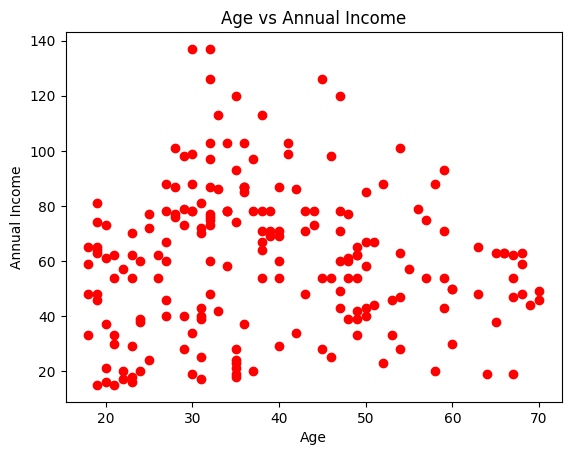

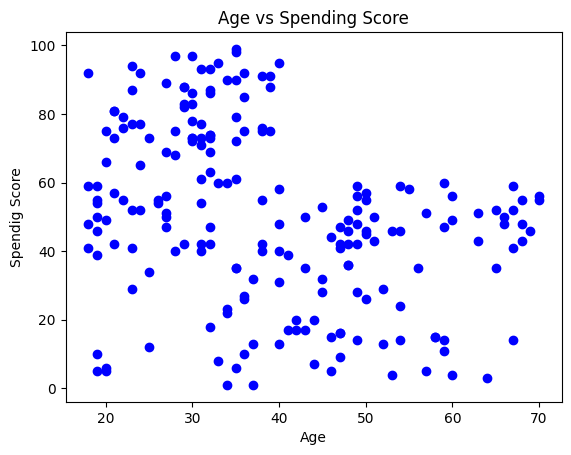

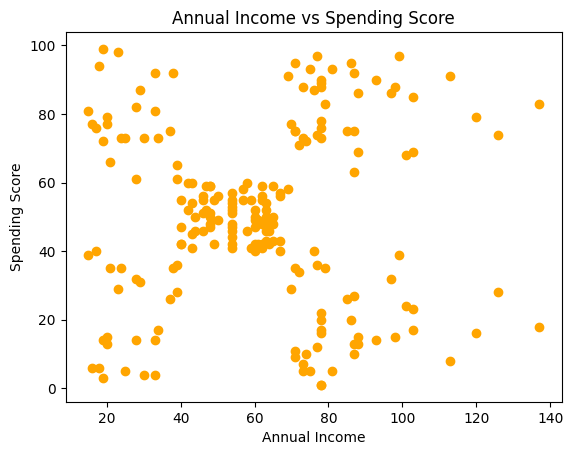

In [5]:
import matplotlib.pyplot as plt
#graficos

#graficos 2D
#"Age" vs. "Annual Income"

plt.title('Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.scatter(datos['Age'], datos['Annual Income (k$)'], color='red')
plt.show()

#"Age" vs. "Spending Score"
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spendig Score')
plt.scatter(datos['Age'], datos['Spending Score (1-100)'], color='blue')
plt.show()

#"Annual Income" vs. "Spending Score

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.scatter(datos['Annual Income (k$)'], datos['Spending Score (1-100)'], color='orange')
plt.show()


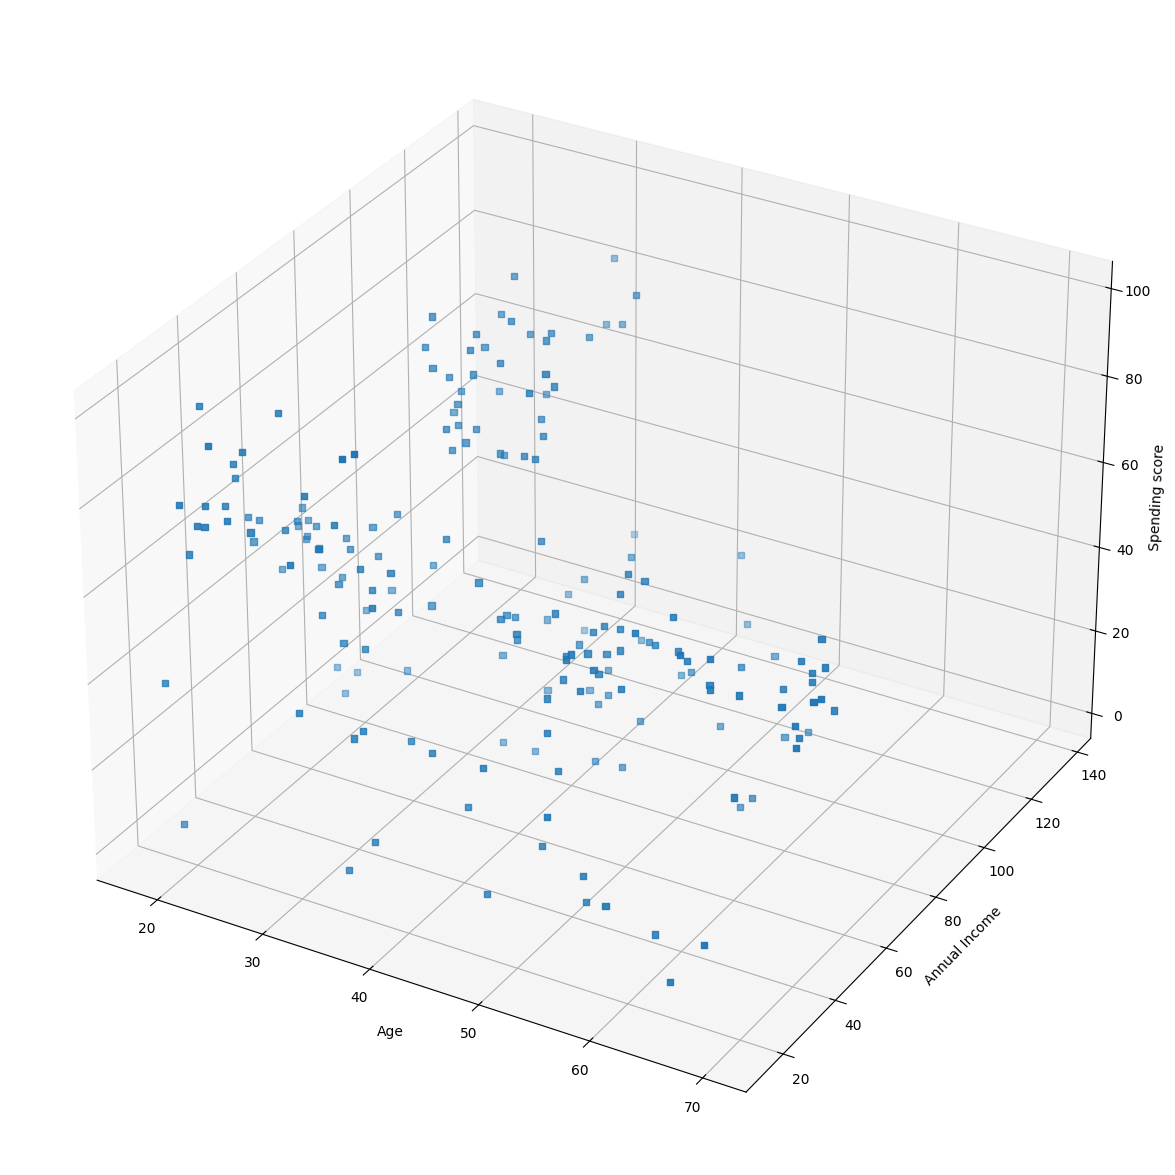

In [6]:
#inicio de grafico 3D
plt.figure(figsize=(15,15))
ax = plt.axes(projection='3d')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending score')

ax.scatter3D(datos['Age'], datos['Annual Income (k$)'], datos['Spending Score (1-100)'], marker='s')

Al ver el grafico, se puede notar que existe una cantidad total de 3 grupos, por lo que se utiliza un algoritmo k-means con K = 3


1. **¿Los clientes con mayor ingresos anuales son los que más gastan?** No lo que sucede es que los que mas gastan son aquellos que tienen in ingreso anual menor o igual que la mediana
2. **¿Los clientes de mayor edad, con mayor ingreso anual, son los que menos gastan?** Si aquellos con la mayor edad suelen ser los que menos gastan

**NOTA:** es posible plantear todas las hipótesis que se desee.

La inertia usando k =  1  es:  67.65023216035944
La inertia usando k =  2  es:  34.74174867905503
La inertia usando k =  3  es:  18.087355563133205
La inertia usando k =  4  es:  15.311014721488794
La inertia usando k =  5  es:  14.015405706005291
La inertia usando k =  6  es:  9.636115790233715


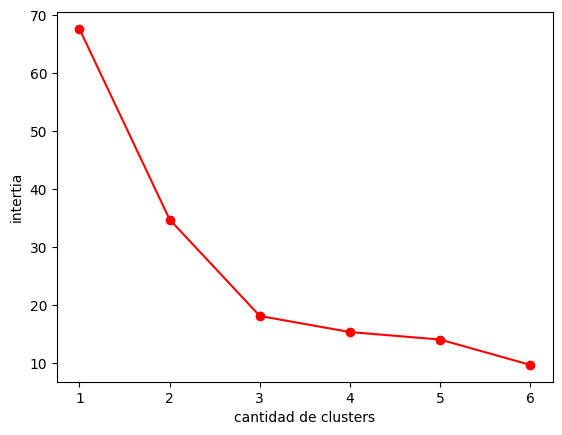

In [ ]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
#comienzo con la normalizacion de los datos, cada dato se encuentra en un  rango de 0 a 1
normalizacion = MinMaxScaler()
datosNormalizados = normalizacion.fit_transform(datos)

#algoritmo k-means

cantidadK = [1,2,3]
intertia = []
for k in cantidadK:
    kmeans= KMeans(k, verbose=0)
    kmeans.fit(datosNormalizados)
    intertia.append(kmeans.inertia_)
    print('La inertia usando k = ', k, ' es: ', kmeans.inertia_)

#grafico para saber cual k es el mejor, cual es el codo

plt.xlabel('cantidad de clusters')
plt.ylabel('intertia')
plt.plot(cantidadK, intertia, marker='o',color='red')
datos['cluster']= kmeans.labels_

Tenemos que en el grafico mostrado anteriormente, se ve que el codo(donde existe una ultima disminucion significativa) es en k = 3 o k = 4


1. **¿Los clientes con mayor ingresos anuales son los que más gastan?** Obteniendo el cuartil Q3 de el ingreso y del gasto, siendo estos mayor que el 0.75% de los datos, podemos comparalos con los datos arrojados de nuestro modelo, concluyendo que uno de los grupos de nuestro modelo, el grupo de indice 1, el mismo tiene la mayor cantidad de ingreso anuales, mayor al 75%, podemos concluir que los clientes con mayor ingreso, son los que menos gastan

In [11]:
#para comprobar la efectividad del cluster, podriamos :
#para saber cuales son los ingresos que mas gastan, deberia primero encontrar la mediana de los datos anuales que se encuentran en el 75% de los datos de spendig score
# una vez realizado eso, compruebo si esa mediana pertenece a el 1er, 2do, 3er o 4to cuartil.


analisis = datos.groupby('cluster').mean()


cuartilIngresos = datos['Annual Income (k$)'].quantile(0.75)
cuartilGasto = datos['Spending Score (1-100)'].quantile(0.75)

print('El 3er cuartil de ingresos es: ', cuartilIngresos)
print('El 3er cuartil de gastos es: ', cuartilGasto)

print(analisis)

cluster_count = datos['cluster'].value_counts()

print(cluster_count.sort_index())


El 3er cuartil de ingresos es:  78.0
El 3er cuartil de gastos es:  73.0
               Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                       
0        30.327869           65.885246               80.983607
1        53.531646           58.962025               35.683544
2        28.183333           57.250000               38.016667
cluster
0    61
1    79
2    60
Name: count, dtype: int64


2. **¿Los clientes de mayor edad, con mayor ingreso anual, son los que menos gastan?** Segun mi hipotesis, tengo que un cliente sera mayor si se encuentra en el 75% de las personas de mayor edad, visualizando se puede ver que el unico grupo donde se considera que las personas son mayores es en el grupo 0. Estas personas, tienen un gasto que se encuentra en el "medio" por lo tanto podemos decir que las personas de mayor edad, tienen un gasto promedio, no elevado. 


In [12]:
# con los datos originales, se puede hacer:
# separao los clientes de mayor edad, los que pertenecen al 4to cuartil
# separo aquellos de mayor ingreso anual, los que estan en el 4to cuartil de el anual
# cuento la cantidad de que adultos que pertenecen al grupo de los que menos gastan
# si los mismos son mas de la mitad de la cantidad de adultos mayores que mas gastan, se tiene que si, ellos son los que menos gastan, sino no.

cuartilEdad = datos['Age'].quantile(0.75)
cuartilGasto = datos['Spending Score (1-100)'].quantile(0.25)
print('Q3 de edad: ',cuartilEdad)
print('Q1 de gasto',cuartilGasto)
print(cluster_count.sort_index())

analisis



Q3 de edad:  49.0
Q1 de gasto 34.75
cluster
0    61
1    79
2    60
Name: count, dtype: int64


,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,30.327869,65.885246,80.983607
1,53.531646,58.962025,35.683544
2,28.183333,57.250000,38.016667
